## Lassine SAVANE

### Elève Ingénieur a l'Ecole Mohammadia d'Ingeniéurs

## Projet: Portefeuille optimal de 10 actions avec le Modèle de Markowitz ##

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import yfinance as yf
import os 
os.getcwd()

'c:\\Users\\Mr SAVANE\\Desktop\\EMI\\MIS\\S2\\Cours\\Python Cours'

#### Telechargement des donnees a partir de Yahoo finance ####

In [120]:
# 10 actifs
actif= [
    "AAPL",      # Apple
    "MSFT",      # Microsoft
    "AMZN",      # Amazon
    "TTE.PA",    # Total Energies
    "MC.PA",     # LVMH
    "NESN.SW",   # Nestlé
    "SONY",      # Sony
    "TSLA",      # Tesla
    "GLD",       # Gold ETF
    "NFLX"       # NetFlix
]

# Téléchargement des prix mensuels réels
data = yf.download(
    actif,
    start="2010-01-01",
    end="2025-01-01",
    interval="1mo"       # journalier pour un max de lignes on peut utiliser 1wk ou 1d
)

# Prix de clôture ajustés
prix = data["Close"]

# Calcul des rendements mensuels en supprimant la ligne initial qui est sans rendement
rendements = prix.pct_change().dropna()

print(f"Dimensions : {rendements.shape}")
print(display(rendements))
print(f"\nMoyennes mensuelles :\n{rendements.mean().round(5)}")
print(f"\nVolatilités :\n{rendements.std().round(5)}")

# Sauvegarder en CSV
rendements.to_csv("DataBase_rendements_Bourse.csv")
print("Fichier sauvegardé !")

[*********************100%***********************]  10 of 10 completed

Dimensions : (174, 10)


Ticker,AAPL,AMZN,GLD,MC.PA,MSFT,NESN.SW,NFLX,SONY,TSLA,TTE.PA
Date,,,,,,,,,,
2010-07-01,0.022740,0.078986,-0.050871,0.042423,0.121686,-0.013410,-0.056144,0.170165,-0.163240,0.047207
2010-08-01,-0.055005,0.058868,0.057061,-0.019761,-0.090663,0.021359,0.223988,-0.103459,-0.023069,-0.047533
2010-09-01,0.167215,0.258191,0.047756,0.172496,0.049026,-0.004753,0.291905,0.104680,0.047741,0.025360
2010-10-01,0.060722,0.052018,0.036823,0.046469,0.089016,0.029608,0.070363,0.101044,0.070063,0.032799
2010-11-01,0.033790,0.061551,0.021113,0.037744,-0.052869,0.012059,0.186265,0.048463,0.617674,-0.044308
...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.031160,-0.045352,0.020922,0.032619,-0.002892,0.021090,0.116177,0.101253,-0.077390,-0.004641
2024-09-01,0.018645,0.043866,0.050889,0.021059,0.033407,-0.066579,0.011293,-0.010148,0.221942,-0.059334
2024-10-01,-0.030429,0.000376,0.042993,-0.114306,-0.055659,-0.039783,0.065927,-0.085587,-0.045025,-0.006283


None

Moyennes mensuelles :
Ticker
AAPL       0.02321
AMZN       0.02496
GLD        0.00498
MC.PA      0.01496
MSFT       0.02024
NESN.SW    0.00517
NFLX       0.03550
SONY       0.01308
TSLA       0.04702
TTE.PA     0.00896
dtype: float64

Volatilités :
Ticker
AAPL       0.07695
AMZN       0.08522
GLD        0.04546
MC.PA      0.06659
MSFT       0.06062
NESN.SW    0.03804
NFLX       0.15726
SONY       0.09495
TSLA       0.18344
TTE.PA     0.06541
dtype: float64
Fichier sauvegardé !


#### Recuperation des donnees a partir de mon repertoire courrant ####

In [121]:
# Chargement des données
df = pd.read_csv("DataBase_rendements_Bourse.csv", index_col=0)
# conversion en tableau numpy pour les calculs de Markowitz
X  = df.values
# calcul des rendements moyens et covariance
mu=df.mean()
sigma=df.cov()
print(mu)
print(sigma)
X.shape

AAPL       0.023211
AMZN       0.024960
GLD        0.004983
MC.PA      0.014962
MSFT       0.020244
NESN.SW    0.005171
NFLX       0.035505
SONY       0.013079
TSLA       0.047015
TTE.PA     0.008955
dtype: float64
             AAPL      AMZN       GLD     MC.PA      MSFT   NESN.SW      NFLX  \
AAPL     0.005921  0.003144  0.000522  0.002164  0.002396  0.000756  0.002356   
AMZN     0.003144  0.007263  0.000567  0.002120  0.002567  0.000569  0.005796   
GLD      0.000522  0.000567  0.002066  0.000388 -0.000026  0.000067  0.000712   
MC.PA    0.002164  0.002120  0.000388  0.004434  0.001613  0.000696  0.002898   
MSFT     0.002396  0.002567 -0.000026  0.001613  0.003675  0.000564  0.003036   
NESN.SW  0.000756  0.000569  0.000067  0.000696  0.000564  0.001447  0.000320   
NFLX     0.002356  0.005796  0.000712  0.002898  0.003036  0.000320  0.024731   
SONY     0.002431  0.002665  0.000141  0.002223  0.002742  0.000761  0.005103   
TSLA     0.005240  0.004995  0.000484  0.002366  0.00275

(174, 10)

#### Modelisation et Calculs ####

In [122]:
#Cacul de la moyenne de chaque actif
def moyenne(x):
    return x.mean(axis=0)
M=moyenne(X)

#calcul de l'ecart type de chaque actif
def ecart_type(x):
    return x.std(axis=0)
E=ecart_type(X)

#Calcul de la matrice de variance-covariance
S=(np.matmul(X.T,X))/X.shape[0]

#Calcul du rendement du portefeuille
def rendement_PF(poids):
    return np.dot(poids,M)

#Calcul du risque du portefeuille
def risque_PF(poids):
    return poids.T @ S @ poids
def volatilite_PF(v):
    return np.sqrt(risque_PF(v))

#la contrainte sur les poids
def const_poids(poids):
    return np.sum(poids)-1
#la contrainte sur la rentabilite
def const_rend(poids):
    return rendement_PF(poids)-0.03
#Bornes des poids
bounds = [(0,1) for i in range(len(M))]

#solution initial 
initial_sol = np.ones(len(M))/len(M)

#Dictionnaire des contraintes
constraints_dict =[{'type': 'eq', 'fun':const_poids},{'type': 'ineq', 'fun':const_rend}]

#Resolution du probleme
resultat = minimize(fun=volatilite_PF,x0=initial_sol, bounds=bounds, constraints=constraints_dict,method="SLSQP")


#### Nuage des points risque-rendement ####

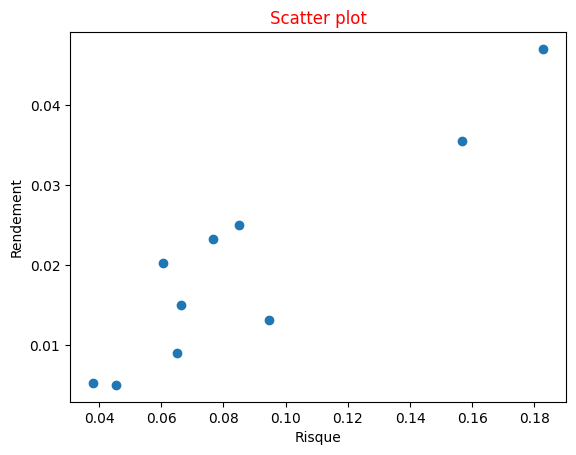

In [123]:
plt.scatter(E, M)
plt.xlabel("Risque")
plt.ylabel('Rendement')
plt.title("Scatter plot",color="red")
plt.show()

#### Affichage du resultat ####

In [124]:
w_optimal = resultat.x

print("      Caracteristiques du Portefeuille Optimal :")
print("\nSa composition est :")
for i, ticker in enumerate(df.columns):
    print(f"  {ticker} : {w_optimal[i]*100:.2f}%")
print("\nSa rentabilité et sa volatilité sont :")
print(f"rentabilité Espérée : {rendement_PF(w_optimal)*100:.2f}%")
print(f"Risque (volatilité) : {volatilite_PF(w_optimal)*100:.2f}%")

      Caracteristiques du Portefeuille Optimal :

Sa composition est :
  AAPL : 21.45%
  AMZN : 13.22%
  GLD : 0.00%
  MC.PA : 0.00%
  MSFT : 26.56%
  NESN.SW : 0.00%
  NFLX : 16.38%
  SONY : 0.00%
  TSLA : 22.40%
  TTE.PA : 0.00%

Sa rentabilité et sa volatilité sont :
rentabilité Espérée : 3.00%
Risque (volatilité) : 8.25%


#### Evolution de Risque-Rendement en fonction du poids ####

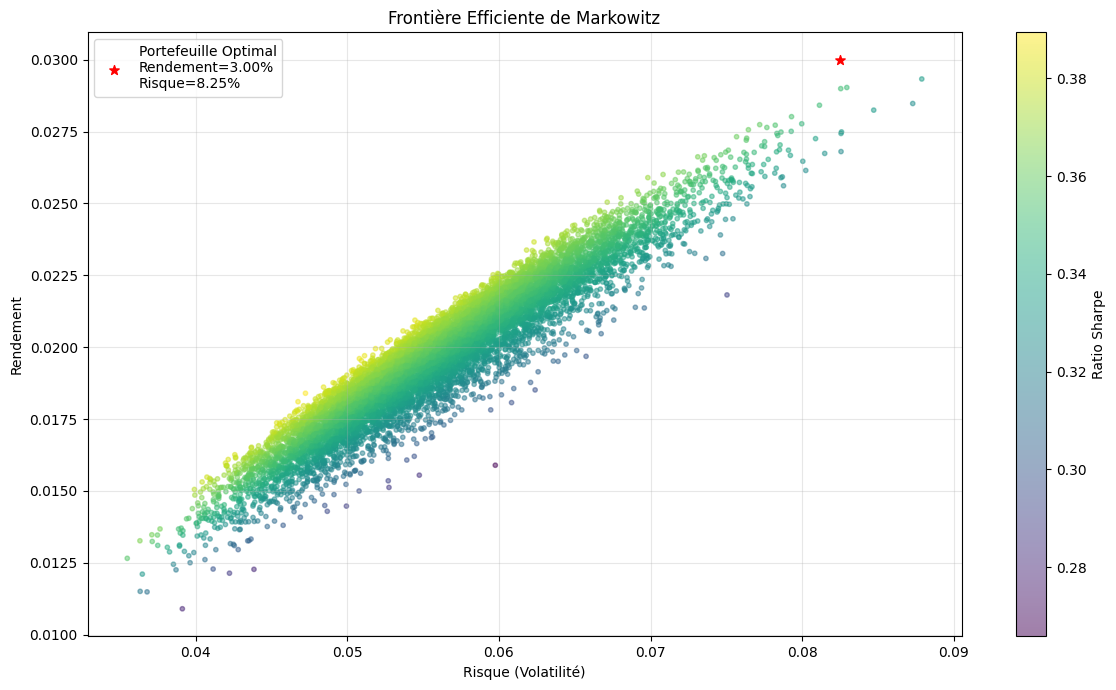

In [125]:
# SIMULATION DE PORTEFEUILLES ALÉATOIRES
n_simulations = 10000
n_actifs = len(M)

rendements_sim = []
risques_sim    = []
poids_sim      = []

for _ in range(n_simulations):
    # Génération des poids aléatoires
    w = np.random.random(n_actifs)
    w = w / np.sum(w)          # normalisation pour que la somme = 1
    
    r = rendement_PF(w)        # rendement du portefeuille
    v = volatilite_PF(w)       # risque du portefeuille
    
    rendements_sim.append(r)
    risques_sim.append(v)
    poids_sim.append(w)

# conversion en tableau numpy
rendements_sim = np.array(rendements_sim)
risques_sim    = np.array(risques_sim)

# TRACÉ DE LA COURBE
plt.figure(figsize=(12, 7))

# Nuage de points des portefeuilles simulés coloré par le ratio Sharpe (rendement/risque)
sharpe = rendements_sim / risques_sim
scatter = plt.scatter(risques_sim, rendements_sim,
                      c=sharpe,
                      cmap="viridis",
                      alpha=0.5,
                      s=10)
#pour afficher les intervalles des valeurs du Ratio de Sharpe
#plus le ratio de sharpe est elevee plus le portefeuille est optimal
plt.colorbar(scatter, label="Ratio Sharpe")

# Portefeuille optimal
w_opt = resultat.x
r_opt = rendement_PF(w_opt)
v_opt = volatilite_PF(w_opt)
#nuage de point du PF_optimal
plt.scatter(v_opt, r_opt,
            color="red",
            marker="*",
            s=50,
            zorder=5,
            label=f"Portefeuille Optimal\nRendement={r_opt*100:.2f}%\nRisque={v_opt*100:.2f}%")

plt.xlabel("Risque (Volatilité)")
plt.ylabel("Rendement")
plt.title("Frontière Efficiente de Markowitz")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()